# 05 — Feature Engineering (FES v1.1, rebuilt on the current pipeline)

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 3.2
Updated 2026-07-14: controlled FES v1.1 migration against Dataset v1.2. This version replaces three sentiment-based occurrence proxies with direct catalogue-count flags and removes three predictors with zero training variance: `labour`, `energy`, and `monetary_x_rate_cut`.

---

## Purpose

Build and freeze `data/processed/feature_matrix.parquet` as FES v1.1 — 92 engineered features across 6 categories — from its two approved inputs. FES v1.1 removes three training-zero-variance predictors (`labour`, `energy`, `monetary_x_rate_cut`) and redefines three occurrence flags from Dataset v1.2 direct counts.

## Inputs

| File | Role |
|------|------|
| `data/processed/master_dataset.parquet` | Dataset v1.2, frozen 2026-07-14 — 2,765 × 34 with direct health/labour/other catalogue-occurrence counts and validation `PASS`. |
| `data/processed/car_results.parquet` | Phase-4 event-study output — regenerated 2026-07-13 by Notebook 04's rerun (264 rows, down from the old frozen 1,796 — a consequence of Notebook 03's current 916-document economic pre-filter, not a defect in this notebook) |

**No other processed artefact is read.** `events_tagged.parquet`, `high_impact_events.parquet`, `gdelt_daily_risk.parquet`, and the legacy `model_features.parquet` are explicitly **not** inputs to this notebook — `feature_contract.md`'s v1.0 scope boundary.

## Outputs

| File | Role |
|------|------|
| `data/processed/feature_matrix.parquet` | FES v1.1: 92 features; final row/split counts are generated and verified by this run |
| `data/processed/feature_profile.json` | Category membership, scaling parameters (train-split mean/std), encoding policy |
| `data/processed/feature_matrix_validation.json` | Duplicate/constant/VIF/correlation/leakage checks, `validation_status` |

**Row-count note (2026-07-13):** the dissertation's frozen v1.0 `feature_matrix.parquet` had 2,511 rows (1,761 train / 750 test). This run has 2,477 rows (1,727 train / 750 test) — 34 fewer, all from the train split. The reason is precise, not approximate: `days_since_car_event`'s validity boundary is set by the first `car_results.parquet` event date that lands on an actual SPY trading day. The chronologically-first event in the current `car_results.parquet`, 2016-01-16, is a Saturday and never matches any trading-calendar row; the first event that does land on a trading day is 2016-02-24 (see Section 5's corrected interpretation cell). The old frozen matrix's boundary was 2016-01-05. Neither number is wrong — both are the correct consequence of their respective `car_results.parquet` inputs.

**Controlled version transition:** the existing FES v1.0 artefacts are compared before saving and archived outside this notebook. FES v1.1 is written only after its validation status is `PASS`; the saved matrix and its inputs are SHA-256-bound in the validation report.

## Research Questions Supported

RQ2 (feature importance — this is the frozen candidate feature set the RF/SHAP ranking runs on) and RQ3 (both `Baseline_LASSO` and the event-enhanced models in Notebooks 06/07 read this file). Not RQ1 directly (RQ1's evidence is `car_results.parquet` itself, produced upstream in Notebook 04).

## Pipeline Position

`04_causal_analysis.ipynb` → **`05_feature_engineering.ipynb`** → `06_model_training.ipynb` → `07_model_evaluation.ipynb` → `08_results_visualisation.ipynb`.

## Scope — this notebook DOES

- Read `master_dataset.parquet` + `car_results.parquet` only
- Build 92 features across Market (27), Macro & VIX (16), Sentiment (23), Event (14), Temporal (5), and Interaction (7) categories
- Apply the warm-up/boundary trim policy (never back-fill or interpolate)
- Compute and persist train-split-only scaling parameters (`StandardScaler`-equivalent, population std)
- Run the full FES v1.1 validation suite (duplicates, variance, VIF, correlation, leakage, occurrence formulas, category counts)
- Compare FES v1.1 with the archived/current FES v1.0 matrix and verify the change surface

## Scope — this notebook does NOT

- Make any feature change beyond the explicitly versioned v1.1 amendment
- Train any predictive model (Notebook 06's job)
- Modify `master_dataset.parquet` or `car_results.parquet` in any way
- Train or report any downstream model result

**Target:** `fwd_return_1d` — forward 1-day SPY log return, unmodified passthrough from `master_dataset.parquet`.


In [4]:
import hashlib
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)

ROOT = Path('..').resolve()
RAW = ROOT / 'data' / 'raw'
PROC = ROOT / 'data' / 'processed'

print(f'ROOT      : {ROOT}')
print(f'PROCESSED : {PROC}')

ROOT      : /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI
PROCESSED : /Users/videnify/Devops/7030DATSCI-Data-Science-Project/7030DATSCI/data/processed


---
## Section 1 — Load Approved Inputs

Per `feature_contract.md`: exactly two processed inputs, no others.

In [5]:
master = pd.read_parquet(PROC / 'master_dataset.parquet').sort_values('date').reset_index(drop=True)
with open(PROC / 'master_dataset_validation.json', encoding='utf-8') as f:
    master_validation = json.load(f)
assert master_validation['dataset_version'] == '1.2'
assert master_validation['validation_status'] == 'PASS'
required_occurrence_cols = [
    'n_health_catalogue_events', 'n_labour_catalogue_events', 'n_other_catalogue_events'
]
assert not (set(required_occurrence_cols) - set(master.columns)), 'Dataset v1.2 occurrence columns missing'
car = pd.read_parquet(PROC / 'car_results.parquet').sort_values('date').reset_index(drop=True)

print(f'master_dataset.parquet : {len(master):,} rows x {master.shape[1]} cols  ({master["date"].min().date()} -> {master["date"].max().date()})')
print(f'car_results.parquet    : {len(car):,} rows x {car.shape[1]} cols  ({car["date"].min().date()} -> {car["date"].max().date()})')

df = master.copy()
train_mask = df['split'] == 'train'

master_dataset.parquet : 2,765 rows x 34 cols  (2015-01-02 -> 2025-12-30)
car_results.parquet    : 264 rows x 14 cols  (2016-01-16 -> 2025-12-06)


---
## Section 2 — Market Features (27)

Price/return and technical-indicator features, derived purely from SPY's own OHLCV — the *only* category the market-only baseline (`Baseline_LASSO`, Notebook 06) may read (`feature_contract.md` Baseline Eligibility table).

In [6]:
# ── Price & return features ────────────────────────────────────────────────────
df['log_return_hi'] = np.log(df['spy_high'] / df['spy_high'].shift(1))
df['log_return_lo'] = np.log(df['spy_low'] / df['spy_low'].shift(1))
df['intraday_range'] = (df['spy_high'] - df['spy_low']) / df['spy_close']
df['volume_ratio'] = df['spy_volume'] / df['spy_volume'].rolling(21).mean()

for n in [1, 3, 5, 10, 21]:
    df[f'return_lag{n}d'] = df['log_return'].shift(n)
for w in [5, 10, 21]:
    df[f'cum_return_{w}d'] = df['log_return'].rolling(w).sum()

# ── Technical indicators ────────────────────────────────────────────────────────
for w in [10, 21, 63]:
    df[f'volatility_{w}d'] = df['log_return'].rolling(w).std()
for w in [21, 63, 126]:
    df[f'momentum_{w}d'] = df['spy_close'] / df['spy_close'].shift(w) - 1

delta = df['spy_close'].diff()
avg_gain = delta.clip(lower=0).rolling(14).mean()
avg_loss = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi_14d'] = 100 - 100 / (1 + avg_gain / avg_loss)
df['rsi_oversold'] = (df['rsi_14d'] < 30).astype(float)
df['rsi_overbought'] = (df['rsi_14d'] > 70).astype(float)

bb_mid = df['spy_close'].rolling(20).mean()
bb_std = df['spy_close'].rolling(20).std()
bb_upper, bb_lower = bb_mid + 2 * bb_std, bb_mid - 2 * bb_std
df['bb_width'] = (bb_upper - bb_lower) / bb_mid
df['bb_position'] = (df['spy_close'] - bb_lower) / (bb_upper - bb_lower)

ma50 = df['spy_close'].rolling(50).mean()
ma200 = df['spy_close'].rolling(200).mean()
df['ma_cross'] = (ma50 > ma200).astype(float)
df['price_vs_ma200'] = df['spy_close'] / ma200 - 1

# Threshold fit on TRAIN split only (leakage-avoidance rule, statistical_assumptions.md)
q75_vol21_train = df.loc[train_mask, 'volatility_21d'].quantile(0.75)
df['high_vol_regime'] = (df['volatility_21d'] > q75_vol21_train).astype(float)

MARKET_FEATURES = [
    'log_return', 'log_return_hi', 'log_return_lo', 'intraday_range', 'volume_ratio',
    'return_lag1d', 'return_lag3d', 'return_lag5d', 'return_lag10d', 'return_lag21d',
    'cum_return_5d', 'cum_return_10d', 'cum_return_21d',
    'volatility_10d', 'volatility_21d', 'volatility_63d',
    'momentum_21d', 'momentum_63d', 'momentum_126d',
    'rsi_14d', 'rsi_oversold', 'rsi_overbought',
    'bb_position', 'bb_width', 'ma_cross', 'price_vs_ma200', 'high_vol_regime',
]
assert len(MARKET_FEATURES) == 27
print(f'Market features built: {len(MARKET_FEATURES)}')

Market features built: 27


---
## Section 3 — Macro & VIX Features (16)

VIX level/regime plus Fed Funds/CPI/yield-curve macro indicators, raw and differenced. Event-model-eligible only (`feature_contract.md`).

In [7]:
df['vix_change_1d'] = df['vix'].diff(1)
df['vix_change_5d'] = df['vix'].diff(5)
df['vix_vs_ma'] = df['vix'] / df['vix'].rolling(21).mean() - 1

q75_vix_train = df.loc[train_mask, 'vix'].quantile(0.75)
df['vix_regime'] = (df['vix'] > q75_vix_train).astype(float)

q90_vixchg_train = df.loc[train_mask, 'vix_change_1d'].quantile(0.90)
df['vix_spike'] = (df['vix_change_1d'] > q90_vixchg_train).astype(float)

df['fed_rate_change'] = df['fed_funds_rate'].diff(21)
df['cpi_mom'] = df['cpi'].diff(21)
df['yield_spread_change'] = df['yield_spread'].diff(5)
df['rate_hike_signal'] = (df['fed_rate_change'] > 0).astype(float)
df['rate_cut_signal'] = (df['fed_rate_change'] < 0).astype(float)
df['inverted_yield'] = (df['yield_spread'] < 0).astype(float)

MACRO_FEATURES = [
    'vix', 'vix_change_1d', 'vix_change_5d', 'vix_vs_ma', 'vix_regime', 'vix_spike',
    'fed_funds_rate', 'yield_spread', 'treasury_10y', 'unemployment',
    'fed_rate_change', 'cpi_mom', 'yield_spread_change',
    'rate_hike_signal', 'rate_cut_signal', 'inverted_yield',
]
assert len(MACRO_FEATURES) == 16
print(f'Macro & VIX features built: {len(MACRO_FEATURES)}')

Macro & VIX features built: 16


---
## Section 4 — Sentiment Features (23)

Daily sentiment aggregates and their rolling/lag transforms. Sourced from `master_dataset.parquet`'s FinBERT-dominant sentiment columns (**Sentiment Engine Freeze v1.0** — FinBERT is the project's official primary sentiment engine; see `10_decision_log.md`). Event-model-eligible only.

In [8]:
for w in [5, 10, 21]:
    df[f'sent_mean_{w}d'] = df['overall_mean_sentiment'].rolling(w).mean()
for w in [5, 10]:
    df[f'sent_std_{w}d'] = df['overall_mean_sentiment'].rolling(w).std()
for w in [5, 10]:
    df[f'sent_momentum_{w}d'] = df['overall_mean_sentiment'] - df[f'sent_mean_{w}d']

df['sent_positive_day'] = (df['overall_mean_sentiment'] > 0).astype(float)
df['sent_negative_day'] = (df['overall_mean_sentiment'] < 0).astype(float)

for cat in ['monetary', 'trade', 'geopolitical']:
    df[f'{cat}_lag1'] = df[cat].shift(1)
    df[f'{cat}_lag5'] = df[cat].shift(5)

SENTIMENT_FEATURES = [
    'overall_mean_sentiment', 'overall_net_sentiment', 'total_events',
    'monetary', 'trade', 'geopolitical', 'regulatory', 'health',
    'sent_mean_5d', 'sent_mean_10d', 'sent_mean_21d',
    'sent_std_5d', 'sent_std_10d',
    'sent_momentum_5d', 'sent_momentum_10d',
    'sent_positive_day', 'sent_negative_day',
    'monetary_lag1', 'monetary_lag5', 'trade_lag1', 'trade_lag5',
    'geopolitical_lag1', 'geopolitical_lag5',
]
assert len(SENTIMENT_FEATURES) == 23
print(f'Sentiment features built: {len(SENTIMENT_FEATURES)}')

Sentiment features built: 23


---
## Section 5 — Event Features (14)

Derived from `car_results.parquet` (11 features) plus three Dataset v1.2 direct-count occurrence flags. Baseline-ineligible — this is the category the market-only baseline must never see.

In [9]:
car_daily = car.groupby('date').agg(
    mean_car=('car', 'mean'),
    n_sig_events=('significant', 'sum'),
).reset_index()

for cat, colname in [
    ('monetary', 'n_monetary_events'), ('geopolitical', 'n_geopolitical_events'),
    ('regulatory', 'n_regulatory_events'), ('trade', 'n_trade_events'),
    ('energy', 'n_energy_events'),
]:
    sub = car[car['event_type'] == cat][['date']].drop_duplicates()
    sub[colname] = 1.0
    car_daily = car_daily.merge(sub, on='date', how='left')

car_daily['car_positive'] = (car_daily['mean_car'] > 0).astype(float)
car_daily['car_negative'] = (car_daily['mean_car'] < 0).astype(float)
car_daily['car_event_day'] = 1.0

df = df.merge(car_daily, on='date', how='left')

_event_fill_cols = ['mean_car', 'n_monetary_events', 'n_geopolitical_events',
                    'n_regulatory_events', 'n_trade_events', 'n_energy_events',
                    'n_sig_events', 'car_positive', 'car_negative', 'car_event_day']
df[_event_fill_cols] = df[_event_fill_cols].fillna(0.0)

# days_since_car_event: trading days since the most recent car_event_day==1
# (current-day event counts as 0; NaN before the first observed event — trimmed
# by the warm-up policy below, never back-filled)
days_since = np.full(len(df), np.nan)
last_event_idx = None
for i in range(len(df)):
    if df.loc[i, 'car_event_day'] == 1.0:
        last_event_idx = i
        days_since[i] = 0
    elif last_event_idx is not None:
        days_since[i] = i - last_event_idx
df['days_since_car_event'] = days_since

df['health_event_day'] = (df['n_health_catalogue_events'] > 0).astype(float)
df['labour_event_day'] = (df['n_labour_catalogue_events'] > 0).astype(float)
df['other_event_day'] = (df['n_other_catalogue_events'] > 0).astype(float)

EVENT_FEATURES = [
    'mean_car', 'n_monetary_events', 'n_geopolitical_events', 'n_regulatory_events',
    'n_trade_events', 'n_energy_events', 'n_sig_events', 'car_positive', 'car_negative',
    'days_since_car_event', 'health_event_day', 'labour_event_day', 'other_event_day',
    'car_event_day',
]
assert len(EVENT_FEATURES) == 14
print(f'Event features built: {len(EVENT_FEATURES)}')

Event features built: 14


**Interpretation — corrected 2026-07-13.** `mean_car` is the single feature that bridges RQ1's event-study finding into RQ2/RQ3 — it is zero-filled on non-event days following the same "true zero, not missing" semantics already established for sentiment (`dataset_version.md`).

`days_since_car_event` remains undefined before the first trading-day-aligned CAR event (2016-02-24), which remains the binding trim boundary. The three health/labour/other flags now use `n_<category>_catalogue_events > 0`, so neutral sentiment no longer erases a genuine event. Dataset v1.2's same-date trading-calendar policy is inherited unchanged.


---
## Section 6 — Temporal Features (5)

Pure calendar features (day-of-week, month, quarter), cyclically encoded where periodic. Deliberately excludes lag/rolling structure (documented once, under Market/Sentiment) and is baseline-ineligible by design, since calendar effects can correlate with scheduled events (e.g. FOMC's fixed cadence).

In [10]:
dow = df['date'].dt.dayofweek  # 0=Mon .. 4=Fri (5-day trading week)
df['dow_sin'] = np.sin(2 * np.pi * dow / 5)
df['dow_cos'] = np.cos(2 * np.pi * dow / 5)

month0 = df['date'].dt.month - 1
df['month_sin'] = np.sin(2 * np.pi * month0 / 12)
df['month_cos'] = np.cos(2 * np.pi * month0 / 12)

df['quarter_num'] = df['date'].dt.quarter.astype(float)

TEMPORAL_FEATURES = ['dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'quarter_num']
assert len(TEMPORAL_FEATURES) == 5
print(f'Temporal features built: {len(TEMPORAL_FEATURES)}')

Temporal features built: 5


---
## Section 7 — Interaction Features (7)

Every interaction multiplies a Market term by an Event/Macro/Sentiment term — baseline-ineligible by construction, even partially.

In [11]:
df['sig_event_x_momentum'] = df['n_sig_events'] * df['momentum_63d']
df['sent_x_vix_regime'] = df['overall_mean_sentiment'] * df['vix_regime']
df['monetary_x_vix'] = df['monetary'] * df['vix']
df['geopolit_x_vix_regime'] = df['geopolitical'] * df['vix_regime']
df['monetary_x_rate_hike'] = df['monetary'] * df['rate_hike_signal']
df['sent_x_high_vol'] = df['overall_mean_sentiment'] * df['high_vol_regime']
df['car_x_sent'] = df['mean_car'] * df['overall_mean_sentiment']

INTERACTION_FEATURES = [
    'sig_event_x_momentum', 'sent_x_vix_regime', 'monetary_x_vix',
    'geopolit_x_vix_regime', 'monetary_x_rate_hike',
    'sent_x_high_vol', 'car_x_sent',
]
assert len(INTERACTION_FEATURES) == 7
print(f'Interaction features built: {len(INTERACTION_FEATURES)}')

CATEGORY_MEMBERSHIP = {
    'market': MARKET_FEATURES, 'macro': MACRO_FEATURES, 'sentiment': SENTIMENT_FEATURES,
    'event': EVENT_FEATURES, 'temporal': TEMPORAL_FEATURES, 'interaction': INTERACTION_FEATURES,
}
ALL_FEATURES = MARKET_FEATURES + MACRO_FEATURES + SENTIMENT_FEATURES + EVENT_FEATURES + TEMPORAL_FEATURES + INTERACTION_FEATURES
assert len(ALL_FEATURES) == 92 and len(set(ALL_FEATURES)) == 92
print(f'\nTotal features: {len(ALL_FEATURES)} (expect 92)')

Interaction features built: 7

Total features: 92 (expect 92)


---
## Section 8 — Assemble, Trim, and Freeze the Matrix

Warm-up/boundary trim policy: drop rows with any NaN in an engineered feature or the target, never back-fill or interpolate (`statistical_analysis_plan.md` Part A). No feature-specific trimming logic is needed — a single `dropna` naturally finds the correct boundary, since `days_since_car_event` (undefined before the first car-event date) is the binding constraint, not any rolling-window warm-up.

In [12]:
TARGET = 'fwd_return_1d'
keep_cols = ['date', 'split'] + ALL_FEATURES + [TARGET]
feature_df = df[keep_cols].copy()

rows_before = len(feature_df)
feature_df = feature_df.dropna(subset=ALL_FEATURES + [TARGET]).reset_index(drop=True)
rows_after = len(feature_df)

print(f'Rows before trim : {rows_before:,}')
print(f'Rows after trim  : {rows_after:,}')
print(f'Rows trimmed     : {rows_before - rows_after:,}')
print(f'Date range       : {feature_df["date"].min().date()} -> {feature_df["date"].max().date()}')
print(f'Columns          : {feature_df.shape[1]}  (2 non-feature + 92 features + 1 target = 95)')
print(f'\nSplit counts:\n{feature_df["split"].value_counts()}')

Rows before trim : 2,765
Rows after trim  : 2,477
Rows trimmed     : 288
Date range       : 2016-02-24 -> 2025-12-29
Columns          : 95  (2 non-feature + 92 features + 1 target = 95)

Split counts:
split
train    1727
test      750
Name: count, dtype: int64


---
## Section 9 — Scaling Parameters (train-split only, persisted not refit)

`feature_matrix.parquet` itself stores **raw, unscaled** values (`feature_contract.md` Scaling Rules) — every consuming notebook applies `(x - mean) / std` using these persisted, train-split-only parameters, never refitting on the full matrix (which would leak test-split distributional information).

In [13]:
train_split = feature_df[feature_df['split'] == 'train']

scaling_parameters = {
    feat: {'mean': float(train_split[feat].mean()), 'std': float(train_split[feat].std(ddof=0))}
    for feat in ALL_FEATURES
}

feature_profile = {
    'feature_matrix_version': '1.1',
    'creation_date': '2026-07-14',
    'notebook_source': '05_feature_engineering.ipynb v3.2 (FES v1.1 migration)',
    'inputs': [
        'data/processed/master_dataset.parquet (Dataset v1.2, frozen 2026-07-14)',
        'data/processed/car_results.parquet (Phase-4 event-study output)',
    ],
    'rows': len(feature_df),
    'rows_by_split': {k: int(v) for k, v in feature_df['split'].value_counts().items()},
    'columns_total': feature_df.shape[1],
    'feature_count': len(ALL_FEATURES),
    'target': TARGET,
    'target_count': 1,
    'non_feature_columns': ['date', 'split'],
    'category_counts': {k: len(v) for k, v in CATEGORY_MEMBERSHIP.items()},
    'category_membership': CATEGORY_MEMBERSHIP,
    'missing_summary': {
        'policy': 'Warm-up/boundary rows trimmed, never back-filled or interpolated (SAP v1.0 Part A)',
        'rows_trimmed_from_master_dataset': rows_before - rows_after,
        'remaining_nulls_in_feature_matrix': int(feature_df[ALL_FEATURES].isna().sum().sum()),
    },
    'scaling': {
        'policy': 'StandardScaler, fit on training split only, applied uniformly to every engineered feature (including binary flags) per SAP v1.0 Part A',
        'fitted_on': 'train split only (chronological, pre-2023-01-03)',
        'stored_where': 'feature_matrix.parquet is UNSCALED by design; parameters below (population std, ddof=0) must be applied by any consuming notebook',
        'parameters': scaling_parameters,
    },
    'encoding': {
        'policy': 'Cyclical sin/cos encoding for calendar periodicity; no other categorical predictors',
        'encoded_features': ['dow_sin', 'dow_cos', 'month_sin', 'month_cos'],
    },
}
print('feature_profile built —', len(scaling_parameters), 'scaling parameters computed (train split, population std).')

feature_profile built — 92 scaling parameters computed (train split, population std).


---
## Section 10 — Validation (FES v1.1 suite + controlled migration comparison)

Two checks govern this freeze: (1) the FES v1.1 validation suite (duplicates, missingness, training variance, correlation, VIF, target/lag leakage, direct-count formulas), and (2) a schema/value comparison against FES v1.0 proving that only the approved change surface moved.

In [14]:
# ── FES v1.1 validation suite ───────────────────────────────────────────────────
VARIANCE_THRESHOLD = 1e-8
CORRELATION_THRESHOLD = 0.90
VIF_THRESHOLD = 10.0

train_features = train_split[ALL_FEATURES].astype(float)
train_variances = train_features.var(ddof=0)
near_zero_variance = {c: float(v) for c, v in train_variances.items() if v < VARIANCE_THRESHOLD}

corr = train_features.corr()
high_correlation_pairs = []
for i, left in enumerate(ALL_FEATURES):
    for right in ALL_FEATURES[i + 1:]:
        value = corr.loc[left, right]
        if pd.notna(value) and abs(value) > CORRELATION_THRESHOLD:
            high_correlation_pairs.append({'left': left, 'right': right, 'r': float(value)})

standardised_train = (train_features - train_features.mean()) / train_features.std(ddof=0)
vif_all = {}
vif_gt_10 = {}
vif_array = standardised_train.to_numpy(dtype=float)
for idx, feature in enumerate(ALL_FEATURES):
    raw_vif = float(variance_inflation_factor(vif_array, idx))
    serialised_vif = raw_vif if np.isfinite(raw_vif) else 'Infinity'
    vif_all[feature] = serialised_vif
    if (not np.isfinite(raw_vif)) or raw_vif > VIF_THRESHOLD:
        vif_gt_10[feature] = serialised_vif

master_target = master.set_index('date')[TARGET].reindex(feature_df['date']).to_numpy(dtype=float)
target_passthrough_exact = bool(np.allclose(feature_df[TARGET].to_numpy(dtype=float), master_target, equal_nan=True))
lag_non_anticipative = bool(np.allclose(
    feature_df['return_lag1d'].iloc[1:].values,
    feature_df['log_return'].iloc[:-1].values, equal_nan=True
))
occurrence_flag_source_checks = {
    'health_event_day': bool((df['health_event_day'] == (df['n_health_catalogue_events'] > 0).astype(float)).all()),
    'labour_event_day': bool((df['labour_event_day'] == (df['n_labour_catalogue_events'] > 0).astype(float)).all()),
    'other_event_day': bool((df['other_event_day'] == (df['n_other_catalogue_events'] > 0).astype(float)).all()),
}

validation = {
    'fes_version': '1.1',
    'dataset_version': '1.2',
    'duplicate_features': [c for c in ALL_FEATURES if ALL_FEATURES.count(c) > 1],
    'missing_values_per_column': {c: int(n) for c, n in feature_df[ALL_FEATURES].isna().sum().items() if n > 0},
    'constant_columns': [c for c in ALL_FEATURES if feature_df[c].nunique() <= 1],
    'near_zero_variance_threshold': VARIANCE_THRESHOLD,
    'near_zero_variance_columns': near_zero_variance,
    'correlation_threshold': CORRELATION_THRESHOLD,
    'high_correlation_pairs': high_correlation_pairs,
    'vif_threshold': VIF_THRESHOLD,
    'vif_all_features': vif_all,
    'vif_gt_10': vif_gt_10,
    'feature_count': len(ALL_FEATURES),
    'target_count': 1,
    'target_name': TARGET,
    'row_count': len(feature_df),
    'rows_by_split': {k: int(v) for k, v in feature_df['split'].value_counts().items()},
    'category_counts': {k: len(v) for k, v in CATEGORY_MEMBERSHIP.items()},
    'target_passthrough_exact': target_passthrough_exact,
    'lag_non_anticipative_spotcheck_return_lag1d': lag_non_anticipative,
    'occurrence_flag_source_checks': occurrence_flag_source_checks,
    'occurrence_flag_nonzero_rows': {c: int(feature_df[c].sum()) for c in ['health_event_day', 'labour_event_day', 'other_event_day']},
    'days_since_car_event_min': float(feature_df['days_since_car_event'].min()),
}
blocking_issues = []
if validation['duplicate_features']: blocking_issues.append('duplicate_features')
if validation['missing_values_per_column']: blocking_issues.append('missing_values')
if validation['constant_columns']: blocking_issues.append('constant_columns')
if validation['near_zero_variance_columns']: blocking_issues.append('near_zero_variance_columns')
if not validation['target_passthrough_exact']: blocking_issues.append('target_passthrough_mismatch')
if not validation['lag_non_anticipative_spotcheck_return_lag1d']: blocking_issues.append('lag_non_anticipative_failure')
if not all(validation['occurrence_flag_source_checks'].values()): blocking_issues.append('occurrence_flag_source_failure')
validation['blocking_issues'] = blocking_issues
validation['validation_status'] = 'FAIL' if blocking_issues else 'PASS'

expected_categories = {'market': 27, 'macro': 16, 'sentiment': 23, 'event': 14, 'temporal': 5, 'interaction': 7}
assert validation['category_counts'] == expected_categories, 'Category counts do not match FES v1.1'
assert validation['row_count'] > 0, 'Feature matrix is empty'
assert set(validation['rows_by_split']) == {'train', 'test'}
assert validation['validation_status'] == 'PASS', f'FES v1.1 validation blocked: {blocking_issues}'

print('=== FES v1.1 VALIDATION SUITE ===')
for key in ['feature_count', 'row_count', 'rows_by_split', 'category_counts',
            'constant_columns', 'near_zero_variance_columns',
            'target_passthrough_exact', 'lag_non_anticipative_spotcheck_return_lag1d',
            'occurrence_flag_source_checks', 'occurrence_flag_nonzero_rows',
            'validation_status']:
    print(f'  {key:<48}: {validation[key]}')
print(f'  high_correlation_pairs (flag only)          : {len(high_correlation_pairs)}')
print(f'  vif_gt_10 (flag only)                       : {len(vif_gt_10)}')

=== FES v1.1 VALIDATION SUITE ===
  feature_count                                   : 92
  row_count                                       : 2477
  rows_by_split                                   : {'train': 1727, 'test': 750}
  category_counts                                 : {'market': 27, 'macro': 16, 'sentiment': 23, 'event': 14, 'temporal': 5, 'interaction': 7}
  constant_columns                                : []
  near_zero_variance_columns                      : {}
  target_passthrough_exact                        : True
  lag_non_anticipative_spotcheck_return_lag1d     : True
  occurrence_flag_source_checks                   : {'health_event_day': True, 'labour_event_day': True, 'other_event_day': True}
  occurrence_flag_nonzero_rows                    : {'health_event_day': 9, 'labour_event_day': 90, 'other_event_day': 306}
  validation_status                               : PASS
  high_correlation_pairs (flag only)          : 7
  vif_gt_10 (flag only)                      

In [15]:
# ── Controlled migration comparison against FES v1.0 ──────────────────────────
_legacy_path = PROC / 'archive' / 'pre_fes_v1_1_2026-07-14' / 'feature_matrix.parquet'
_current_path = PROC / 'feature_matrix.parquet'
frozen = None
comparison_source = None
if _legacy_path.exists():
    frozen = pd.read_parquet(_legacy_path)
    comparison_source = str(_legacy_path)
elif _current_path.exists():
    candidate = pd.read_parquet(_current_path)
    if {'energy', 'labour', 'monetary_x_rate_cut'}.issubset(candidate.columns):
        frozen = candidate
        comparison_source = str(_current_path)
print('=== FES v1.1 MIGRATION COMPARISON vs. FES v1.0 ===')
if frozen is not None:
    frozen_sorted = frozen.sort_values('date').set_index('date')
    new_sorted = feature_df.sort_values('date').set_index('date')
    legacy_features = set(frozen.columns) - {'date', 'split', TARGET}
    new_features = set(ALL_FEATURES)
    removed_features = sorted(legacy_features - new_features)
    added_features = sorted(new_features - legacy_features)
    common_features = sorted(legacy_features & new_features)
    common_dates = frozen_sorted.index.intersection(new_sorted.index)
    changed_features = {}
    for feature in common_features:
        old_values = frozen_sorted.loc[common_dates, feature].astype(float).to_numpy()
        new_values = new_sorted.loc[common_dates, feature].astype(float).to_numpy()
        maxdiff = float(np.nanmax(np.abs(old_values - new_values)))
        changed_rows = int((~np.isclose(old_values, new_values, atol=1e-12, equal_nan=True)).sum())
        if changed_rows:
            changed_features[feature] = {'changed_rows': changed_rows, 'max_abs_diff': maxdiff}
    expected_changed = {'health_event_day', 'labour_event_day', 'other_event_day'}
    MIGRATION_DELTA_VALIDATED = (
        removed_features == ['energy', 'labour', 'monetary_x_rate_cut']
        and added_features == []
        and set(changed_features) == expected_changed
        and frozen_sorted.index.equals(new_sorted.index)
    )
    validation['migration_comparison'] = {
        'previous_version': '1.0',
        'comparison_source': comparison_source,
        'removed_features': removed_features,
        'added_features': added_features,
        'redefined_features': changed_features,
        'row_index_unchanged': bool(frozen_sorted.index.equals(new_sorted.index)),
        'migration_delta_validated': bool(MIGRATION_DELTA_VALIDATED),
    }
    assert MIGRATION_DELTA_VALIDATED, f'Unexpected FES v1.1 change surface: {validation["migration_comparison"]}'
    print(f'  Removed features : {removed_features}')
    print(f'  Added features   : {added_features}')
    print(f'  Redefined        : {changed_features}')
    print(f'  Row index same   : {frozen_sorted.index.equals(new_sorted.index)}')
    print(f'  MIGRATION_DELTA_VALIDATED = {MIGRATION_DELTA_VALIDATED}')
else:
    MIGRATION_DELTA_VALIDATED = None
    validation['migration_comparison'] = {
        'previous_version': '1.0',
        'comparison_source': None,
        'status': 'NOT_AVAILABLE_ON_CLEAN_REBUILD',
        'migration_delta_validated': None,
    }
    print('  Legacy FES v1.0 reference unavailable; exact historical delta check skipped.')
    print('  Current FES v1.1 formula/source/variance/leakage checks still govern the build.')

=== FES v1.1 MIGRATION COMPARISON vs. FES v1.0 ===
  Removed features : ['energy', 'labour', 'monetary_x_rate_cut']
  Added features   : []
  Redefined        : {'health_event_day': {'changed_rows': 7, 'max_abs_diff': 1.0}, 'labour_event_day': {'changed_rows': 90, 'max_abs_diff': 1.0}, 'other_event_day': {'changed_rows': 299, 'max_abs_diff': 1.0}}
  Row index same   : True
  MIGRATION_DELTA_VALIDATED = True


**Interpretation (FES v1.1 migration).** The dated FES v1.0 archive is used as the change-control baseline when available, so repeat executions do not mistake the current FES v1.1 file for the old version. The permitted schema delta is removal of `labour`, `energy`, and `monetary_x_rate_cut`; the permitted value delta is limited to `health_event_day`, `labour_event_day`, and `other_event_day`. On a clean rebuild with no historical matrix, this retrospective comparison is recorded as unavailable rather than fabricated; all current formula/source/variance/leakage checks remain blocking.


---
## Section 11 — Save and Freeze FES v1.1

This controlled version transition writes the canonical FES v1.1 artefacts only after validation and migration-delta assertions pass. The matrix, validation report, profile, and both approved inputs are SHA-256-bound. The previous FES v1.0 artefacts are archived before notebook execution.


In [16]:
assert validation['validation_status'] == 'PASS'
assert MIGRATION_DELTA_VALIDATED is not False

matrix_path = PROC / 'feature_matrix.parquet'
profile_path = PROC / 'feature_profile.json'
validation_path = PROC / 'feature_matrix_validation.json'
feature_df.to_parquet(matrix_path, index=False)

def _sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

artifact_sha = _sha256(matrix_path)
input_hashes = {
    'master_dataset.parquet': _sha256(PROC / 'master_dataset.parquet'),
    'car_results.parquet': _sha256(PROC / 'car_results.parquet'),
}
feature_profile['artifact_sha256'] = artifact_sha
feature_profile['input_sha256'] = input_hashes
validation['artifact'] = 'data/processed/feature_matrix.parquet'
validation['artifact_sha256'] = artifact_sha
validation['input_sha256'] = input_hashes

with open(profile_path, 'w', encoding='utf-8') as f:
    json.dump(feature_profile, f, indent=2, default=str)
    f.write('\n')
with open(validation_path, 'w', encoding='utf-8') as f:
    json.dump(validation, f, indent=2, default=str)
    f.write('\n')
print(f'  feature_matrix.parquet           frozen FES v1.1  sha256={artifact_sha}')
print('  feature_profile.json            written')
print('  feature_matrix_validation.json  written (PASS)')

  feature_matrix.parquet           frozen FES v1.1  sha256=127a6dbe4b83e59c873dfdf7502060aab115037732bbb723f9d489c6b85dc383
  feature_profile.json            written
  feature_matrix_validation.json  written (PASS)


In [17]:
saved_matrix = pd.read_parquet(PROC / 'feature_matrix.parquet')
with open(PROC / 'feature_profile.json', encoding='utf-8') as f:
    saved_profile = json.load(f)
with open(PROC / 'feature_matrix_validation.json', encoding='utf-8') as f:
    saved_validation = json.load(f)
assert saved_matrix.shape == feature_df.shape
assert list(saved_matrix.columns) == list(feature_df.columns)
assert saved_profile['feature_matrix_version'] == '1.1'
assert saved_validation['validation_status'] == 'PASS'
assert saved_validation['artifact_sha256'] == _sha256(PROC / 'feature_matrix.parquet')
print(f'✓ Persisted FES v1.1 verified: {saved_matrix.shape[0]:,} rows × {len(ALL_FEATURES)} features; validation PASS; hash match')

✓ Persisted FES v1.1 verified: 2,477 rows × 92 features; validation PASS; hash match


**Interpretation (FES v1.1).** The validation failure that required the FES v1.0 known exception is resolved structurally. The three training-zero-variance predictors (`labour`, `energy`, `monetary_x_rate_cut`) are removed; `labour_event_day` is retained and now measures direct catalogue presence. The saved validation must report `PASS` with no constant or near-zero-variance feature before downstream retraining is allowed. Correlation and VIF exceedances remain interpretability flags, not automatic deletion rules, exactly as frozen in the SAP.


---
## Learning Outcome (added 2026-07-13)

A quick visual summary of what this notebook actually built — for readers who want the shape of the result at a glance rather than reading through the numeric cells above.


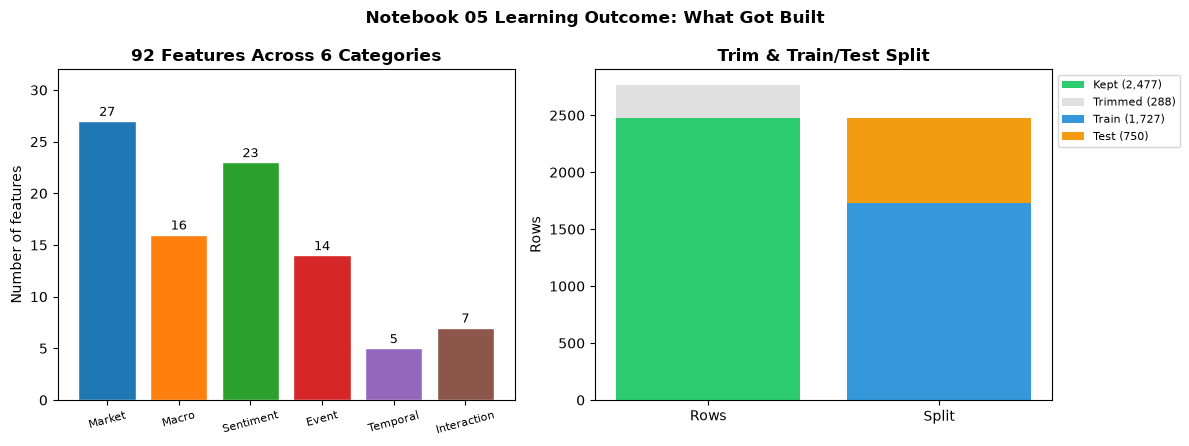

✓ Saved reports/figures/05_learning_outcome.png
  Left: 92 features in 6 categories (Market is the only baseline-eligible one).
  Right: 2,765 raw rows -> 2,477 kept after trim (288 dropped for warm-up/boundary NaNs), split into 1,727 train / 750 test rows.


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: feature count per category
ax = axes[0]
cats = list(CATEGORY_MEMBERSHIP.keys())
counts = [len(v) for v in CATEGORY_MEMBERSHIP.values()]
colors = plt.cm.tab10.colors[:len(cats)]
bars = ax.bar([c.capitalize() for c in cats], counts, color=colors, edgecolor='white')
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, c + 0.5, str(c), ha='center', fontsize=9)
ax.set_ylabel('Number of features')
ax.set_title(f'{len(ALL_FEATURES)} Features Across 6 Categories', fontweight='bold')
ax.set_ylim(0, max(counts) + 5)
ax.tick_params(axis='x', labelsize=8, labelrotation=15)

# Panel 2: rows kept vs trimmed, and train/test split
ax2 = axes[1]
kept = rows_after
trimmed = rows_before - rows_after
ax2.bar(['Rows'], [kept], color='#2ecc71', label=f'Kept ({kept:,})')
ax2.bar(['Rows'], [trimmed], bottom=[kept], color='#e0e0e0', label=f'Trimmed ({trimmed:,})')
train_n = int((feature_df['split'] == 'train').sum())
test_n = int((feature_df['split'] == 'test').sum())
ax2.bar(['Split'], [train_n], color='#3498db', label=f'Train ({train_n:,})')
ax2.bar(['Split'], [test_n], bottom=[train_n], color='#f39c12', label=f'Test ({test_n:,})')
ax2.set_ylabel('Rows')
ax2.set_title('Trim & Train/Test Split', fontweight='bold')
ax2.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.0, 1.0))

fig.suptitle('Notebook 05 Learning Outcome: What Got Built', fontsize=12, fontweight='bold')
plt.tight_layout()
fig_path = FIG_DIR if 'FIG_DIR' in dir() else PROC.parent.parent / 'reports' / 'figures'
fig_path = (PROC.parent.parent / 'reports' / 'figures')
fig_path.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path / '05_learning_outcome.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved reports/figures/05_learning_outcome.png")
print(f"  Left: {len(ALL_FEATURES)} features in 6 categories (Market is the only baseline-eligible one).")
print(f"  Right: {rows_before:,} raw rows -> {rows_after:,} kept after trim ({trimmed:,} dropped for warm-up/boundary NaNs), "
      f"split into {train_n:,} train / {test_n:,} test rows.")

In [19]:
print('=' * 65)
print('PHASE 5 — FEATURE ENGINEERING (FES v1.1 FREEZE): SUMMARY')
print('=' * 65)

print(f'\nFEATURE MATRIX')
print(f'  Total rows          : {len(feature_df):,}')
print(f'  Total features      : {len(ALL_FEATURES)}')
print(f'  Date range          : {feature_df["date"].min().date()} -> {feature_df["date"].max().date()}')

print(f'\nFEATURE CATEGORIES')
for cat, feats in CATEGORY_MEMBERSHIP.items():
    print(f'  {cat.capitalize():<12}: {len(feats)}')

print(f'\nTRAIN / TEST SPLIT')
print(f'  Train               : {(feature_df["split"]=="train").sum():,} rows')
print(f'  Test                : {(feature_df["split"]=="test").sum():,} rows')

print(f'\nVALIDATION STATUS   : {validation["validation_status"]}')
print(f'MIGRATION VALIDATED  : {MIGRATION_DELTA_VALIDATED}')

print(f'\nOUTPUTS  ->  data/processed/')
print(f'  feature_matrix.parquet')
print(f'  feature_profile.json')
print(f'  feature_matrix_validation.json')

print(f'\nNEXT: Notebook 06 — Baseline Model (Baseline_LASSO, MCP v1.0)')
print('=' * 65)

PHASE 5 — FEATURE ENGINEERING (FES v1.1 FREEZE): SUMMARY

FEATURE MATRIX
  Total rows          : 2,477
  Total features      : 92
  Date range          : 2016-02-24 -> 2025-12-29

FEATURE CATEGORIES
  Market      : 27
  Macro       : 16
  Sentiment   : 23
  Event       : 14
  Temporal    : 5
  Interaction : 7

TRAIN / TEST SPLIT
  Train               : 1,727 rows
  Test                : 750 rows

VALIDATION STATUS   : PASS
MIGRATION VALIDATED  : True

OUTPUTS  ->  data/processed/
  feature_matrix.parquet
  feature_profile.json
  feature_matrix_validation.json

NEXT: Notebook 06 — Baseline Model (Baseline_LASSO, MCP v1.0)


## Section Summary & Handoff to Notebook 06

Notebook 05 freezes `feature_matrix.parquet` as FES v1.1 from Dataset v1.2 plus the current `car_results.parquet`. The versioned amendment removes `labour`, `energy`, and `monetary_x_rate_cut` because each has zero training variance, and redefines `health_event_day`, `labour_event_day`, and `other_event_day` from direct catalogue counts. The controlled comparison asserts that no other feature, target, date, or split changed.

It does not train any model. Notebook 06 remains restricted to the unchanged 27 Market features, while Notebook 07 will consume the 92-feature event-enhanced matrix. Both notebooks must be rerun before any FES v1.1 model metric or dissertation result is reported.
